In [19]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [20]:
class BatsmanState(TypedDict):

    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    summary: str

In [27]:
def calculate_sr(state: BatsmanState):

    sr = (state['runs']/state['balls'])*100

    return {'sr': sr}

In [28]:
def calculate_bpb(state: BatsmanState) -> BatsmanState:

    bpb = state['balls']/(state['fours'] + state['sixes'])

    return {'bpb': bpb}

In [29]:
def calculate_boundry_percent(state: BatsmanState) -> BatsmanState:

    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs'])*100

    return {'boundary_percent':boundary_percent}

In [30]:
def summary(state: BatsmanState) -> BatsmanState:

    summary = f"""
State Rate: {state['sr']} \n
Balls per boundary: {state['bpb']} \n 
Boundary Percent: {state['boundary_percent']} \n 
"""

    return {'summary': summary}

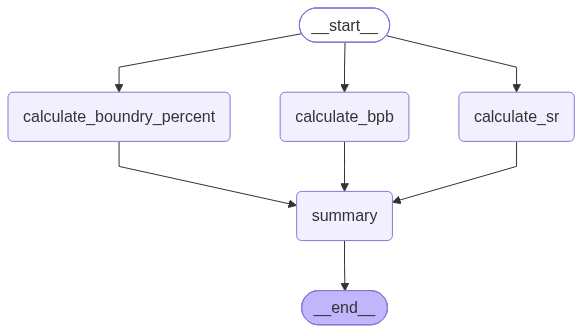

In [31]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_sr", calculate_sr)
graph.add_node("calculate_bpb", calculate_bpb)
graph.add_node("calculate_boundry_percent", calculate_boundry_percent)
graph.add_node("summary", summary)


graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundry_percent')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundry_percent', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

workflow

In [32]:
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}


workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'summary': '\nState Rate: 200.0 \n\nBalls per boundary: 5.0 \n \nBoundary Percent: 48.0 \n \n'}